## Resumen
Este notebook compara la media de fillgaps contra la media implicita de los 1000 bins (vintage 20260922), con foco en Malawi, e incluye chequeos por anio y revision de bins de la cola alta.

# Malawi: Fillgaps vs 1000-bin mean, vintage 20260922

Objective: use the new `fillgaps.dta` file as the PIP/fillgaps benchmark and compute the average welfare implied by the 1000-bin distribution for Malawi in the same vintage.

Important: `fillgaps.dta` is already an aggregate PIP-style file. It does not contain microdata, so the bins are not reconstructed from `fillgaps.dta`; the 1000-bin mean is computed from the corresponding `GlobalDist1000bins` file.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 2. Paths

In [ ]:
ROOT = Path(".").resolve()
INPUT = ROOT / "01-input"
OUT = ROOT / "work"

fillgaps_path = INPUT / "20260922" / "fillgaps.dta"

# In the current folder structure, the 20260922 GlobalDist file is inside nuevosyuki.
# If later you move it into 01-input/20260922, this code will automatically use it there.
global_bins_candidates = [
    INPUT / "20260922" / "GlobalDist1000bins_1990_2026_20260922_2021_01_02_PROD.dta",
    INPUT / "nuevosyuki" / "GlobalDist1000bins_1990_2026_20260922_2021_01_02_PROD.dta",
]
global_bins_path = next((p for p in global_bins_candidates if p.exists()), None)

fillgaps_path, global_bins_path

(PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/20260922/fillgaps.dta'),
 PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/nuevosyuki/GlobalDist1000bins_1990_2026_20260922_2021_01_02_PROD.dta'))

## 3. Load Malawi from fillgaps

In [3]:
fillgaps = pd.read_stata(fillgaps_path, convert_categoricals=False)
fillgaps["year"] = fillgaps["year"].astype(int)

mwi_fillgaps = fillgaps[
    (fillgaps["country_code"] == "MWI")
    & (fillgaps["reporting_level"] == "national")
].copy()

mwi_fillgaps = mwi_fillgaps.sort_values("year")

mwi_fillgaps[[
    "country_code", "country_name", "year", "welfare_type", "reporting_level",
    "mean", "population", "is_interpolated", "estimate_type"
]].head(20)

,country_code,country_name,year,welfare_type,reporting_level,mean,population,is_interpolated,estimate_type
6394,MWI,Malawi,1981,1,national,5.516035,6516454,TRUE,projection
6395,MWI,Malawi,1982,1,national,5.459481,6778879,TRUE,projection
6396,MWI,Malawi,1983,1,national,5.448240,7051709,TRUE,projection
6397,MWI,Malawi,1984,1,national,5.498632,7332810,TRUE,projection
6398,MWI,Malawi,1985,1,national,5.522615,7620508,TRUE,projection
6399,MWI,Malawi,1986,1,national,5.374790,7906480,TRUE,projection
6400,MWI,Malawi,1987,1,national,5.257657,8293174,TRUE,projection
6401,MWI,Malawi,1988,1,national,5.175002,8753262,TRUE,projection
6402,MWI,Malawi,1989,1,national,5.054500,9176220,TRUE,projection
6403,MWI,Malawi,1990,1,national,5.111098,9545852,TRUE,projection


## 4. Compute Malawi mean from the 1000 bins

In [4]:
if global_bins_path is None:
    raise FileNotFoundError("Could not find the 20260922 GlobalDist1000bins file in the expected folders.")

chunks = []
for chunk in pd.read_stata(
    global_bins_path,
    columns=["code", "year", "quantile", "welf", "pop"],
    chunksize=500_000,
):
    chunk["year"] = chunk["year"].astype(int)
    keep = chunk["code"].eq("MWI")
    if keep.any():
        chunks.append(chunk.loc[keep].copy())

mwi_bins = pd.concat(chunks, ignore_index=True)
mwi_bins["quantile"] = mwi_bins["quantile"].astype(int)

mwi_bins.head(), mwi_bins.tail()

(  code  year  quantile     welf      pop
 0  MWI  1990         1 0.288558 0.009546
 1  MWI  1990         2 0.316055 0.009546
 2  MWI  1990         3 0.351684 0.009546
 3  MWI  1990         4 0.371769 0.009546
 4  MWI  1990         5 0.388778 0.009546,
       code  year  quantile      welf      pop
 36995  MWI  2026       996 15.939103 0.022786
 36996  MWI  2026       997 17.537951 0.022786
 36997  MWI  2026       998 19.273780 0.022786
 36998  MWI  2026       999 21.390005 0.022786
 36999  MWI  2026      1000 41.801204 0.022786)

## 5. Collapse the 1000 bins to one mean per year

In [5]:
# Because the bin file includes population per bin, the safest mean is the population-weighted mean.
# If all bins have equal population, this is almost identical to the simple average across 1000 bins.

def weighted_mean(g):
    return np.average(g["welf"], weights=g["pop"])

mwi_bin_means = (
    mwi_bins
    .groupby(["code", "year"], as_index=False)
    .agg(
        n_bins=("quantile", "size"),
        simple_mean_1kbins=("welf", "mean"),
        total_pop_bins=("pop", "sum"),
    )
)

weighted = (
    mwi_bins
    .groupby(["code", "year"])
    .apply(weighted_mean, include_groups=False)
    .reset_index(name="weighted_mean_1kbins")
)

mwi_bin_means = mwi_bin_means.merge(weighted, on=["code", "year"], how="left")
mwi_bin_means.head(20)

,code,year,n_bins,simple_mean_1kbins,total_pop_bins,weighted_mean_1kbins
0,MWI,1990,1000,4.344777,9.545852,4.344777
1,MWI,1991,1000,4.510060,9.844227,4.510060
2,MWI,1992,1000,4.194608,10.135079,4.194608
3,MWI,1993,1000,4.432527,10.284024,4.432527
4,MWI,1994,1000,4.147447,10.164894,4.147447
5,MWI,1995,1000,4.638040,10.150117,4.638040
6,MWI,1996,1000,4.807560,10.352228,4.807560
7,MWI,1997,1000,4.865801,10.562035,4.865801
8,MWI,1998,1000,4.855069,10.792876,4.855069
9,MWI,1999,1000,4.412598,11.047804,4.412598


## 6. Compare fillgaps mean vs 1000-bin mean

In [6]:
comparison = mwi_fillgaps.merge(
    mwi_bin_means,
    left_on=["country_code", "year"],
    right_on=["code", "year"],
    how="inner",
)

comparison["diff_fillgaps_minus_bins"] = comparison["mean"] - comparison["weighted_mean_1kbins"]
comparison["abs_diff"] = comparison["diff_fillgaps_minus_bins"].abs()
comparison["pct_diff_vs_fillgaps"] = comparison["diff_fillgaps_minus_bins"] / comparison["mean"]

cols = [
    "country_code", "year", "welfare_type", "mean", "weighted_mean_1kbins",
    "simple_mean_1kbins", "diff_fillgaps_minus_bins", "pct_diff_vs_fillgaps",
    "n_bins", "population", "total_pop_bins", "is_interpolated", "estimate_type"
]

comparison[cols].sort_values("year")

,country_code,year,welfare_type,mean,weighted_mean_1kbins,simple_mean_1kbins,diff_fillgaps_minus_bins,pct_diff_vs_fillgaps,n_bins,population,total_pop_bins,is_interpolated,estimate_type
0,MWI,1990,1,5.111098,4.344777,4.344777,0.766321,0.149933,1000,9545852,9.545852,TRUE,projection
1,MWI,1991,1,5.305533,4.510060,4.510060,0.795473,0.149933,1000,9844227,9.844227,TRUE,projection
2,MWI,1992,1,4.934442,4.194608,4.194608,0.739834,0.149933,1000,10135079,10.135079,TRUE,projection
3,MWI,1993,1,5.214325,4.432527,4.432527,0.781798,0.149933,1000,10284024,10.284024,TRUE,projection
4,MWI,1994,1,4.878963,4.147447,4.147447,0.731516,0.149933,1000,10164894,10.164894,TRUE,projection
5,MWI,1995,1,5.456085,4.638040,4.638040,0.818046,0.149933,1000,10150117,10.150117,TRUE,projection
6,MWI,1996,1,5.655505,4.807560,4.807560,0.847945,0.149933,1000,10352228,10.352228,TRUE,projection
7,MWI,1997,1,5.724018,4.865801,4.865801,0.858217,0.149933,1000,10562035,10.562035,TRUE,projection
8,MWI,1998,1,5.711309,4.855069,4.855069,0.856239,0.149920,1000,10792876,10.792876,TRUE,projection
9,MWI,1999,1,5.266591,4.412598,4.412598,0.853994,0.162153,1000,11047804,11.047804,TRUE,projection


## 7. Malawi 1997 check

In [7]:
comparison_1997 = comparison.loc[comparison["year"] == 1997, cols]
comparison_1997

,country_code,year,welfare_type,mean,weighted_mean_1kbins,simple_mean_1kbins,diff_fillgaps_minus_bins,pct_diff_vs_fillgaps,n_bins,population,total_pop_bins,is_interpolated,estimate_type
7,MWI,1997,1,5.724018,4.865801,4.865801,0.858217,0.149933,1000,10562035,10.562035,TRUE,projection


## 8. Top bins for Malawi 1997

In [8]:
mwi_bins_1997 = mwi_bins[mwi_bins["year"] == 1997].copy()
mwi_bins_1997.sort_values("quantile").tail(15)

,code,year,quantile,welf,pop
7985,MWI,1997,986,20.724538,0.010562
7986,MWI,1997,987,21.423881,0.010562
7987,MWI,1997,988,21.896685,0.010562
7988,MWI,1997,989,22.744716,0.010562
7989,MWI,1997,990,25.060238,0.010562
7990,MWI,1997,991,26.902205,0.010562
7991,MWI,1997,992,28.555092,0.010562
7992,MWI,1997,993,31.416913,0.010562
7993,MWI,1997,994,35.714648,0.010562
7994,MWI,1997,995,38.615624,0.010562


## 9. Graph over time

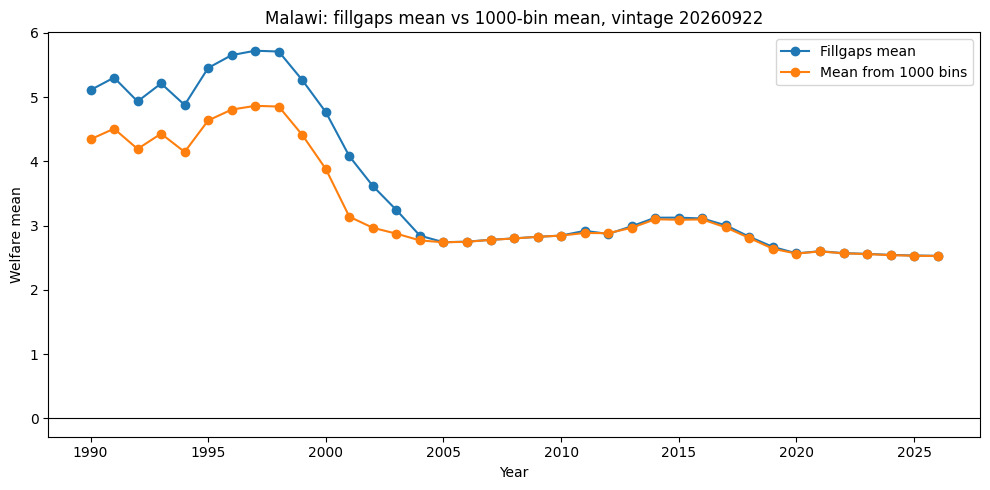

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(comparison["year"], comparison["mean"], marker="o", linewidth=1.5, label="Fillgaps mean")
ax.plot(comparison["year"], comparison["weighted_mean_1kbins"], marker="o", linewidth=1.5, label="Mean from 1000 bins")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Malawi: fillgaps mean vs 1000-bin mean, vintage 20260922")
ax.set_xlabel("Year")
ax.set_ylabel("Welfare mean")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Save outputs

In [10]:
OUT.mkdir(exist_ok=True)

comparison_out = OUT / "MWI_20260922_fillgaps_vs_1kbins.csv"
topbins_out = OUT / "MWI_20260922_top_bins_1997.csv"

comparison[cols].sort_values("year").to_csv(comparison_out, index=False)
mwi_bins_1997.sort_values("quantile").tail(50).to_csv(topbins_out, index=False)

comparison_out, topbins_out

(PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/work/MWI_20260922_fillgaps_vs_1kbins.csv'),
 PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/work/MWI_20260922_top_bins_1997.csv'))